In [2]:
# Cell No: 1
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import time
import matplotlib.pyplot as plt

In [3]:
# Cell No: 2
def load_data():
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()

    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)

    return x_train, y_train, x_test, y_test

In [4]:
# Cell No: 3
def get_activation(x, name):
    if name == "relu":
        return layers.ReLU()(x)
    elif name == "leaky_relu":
        return layers.LeakyReLU(alpha=0.1)(x)
    elif name == "elu":
        return layers.ELU()(x)
    else:
        raise ValueError("Unsupported activation")

In [5]:
# Cell No: 4
def build_model(activation_name):
    inputs = layers.Input(shape=(32,32,3))

    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = get_activation(x, activation_name)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = get_activation(x, activation_name)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = get_activation(x, activation_name)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    return Model(inputs, outputs)

In [6]:
# Cell No: 5
def train_model(model, x_train, y_train):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()

    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=64,
        verbose=1
    )

    end = time.time()

    return history, end - start

In [7]:
# Cell No: 6
def run_activation_experiment():
    x_train, y_train, x_test, y_test = load_data()

    activations = ["relu", "leaky_relu", "elu"]
    results = {}

    for act in activations:
        print(f"\nRunning: {act}")

        model = build_model(act)
        history, train_time = train_model(model, x_train, y_train)

        loss, acc = model.evaluate(x_test, y_test, verbose=0)

        results[act] = {
            "history": history.history,
            "time": train_time,
            "test_acc": acc
        }

    return results

In [8]:
# Cell No: 7
def plot_activation_results(results):
    plt.figure()

    for act, data in results.items():
        plt.plot(data["history"]["val_accuracy"], label=act)

    plt.title("Validation Accuracy Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

Running: relu
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3137 - loss: 1.8183 - val_accuracy: 0.4128 - val_loss: 1.6088
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4460 - loss: 1.5244 - val_accuracy: 0.4794 - val_loss: 1.4558
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4983 - loss: 1.3901 - val_accuracy: 0.5095 - val_loss: 1.3446
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5317 - loss: 1.3039 - val_accuracy: 0.5548 - val_loss: 1.2539
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5565 - loss: 1.2380 - val_accuracy: 0.5599 - val_loss: 1.2257
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5818 - loss: 1.1769 - val_accuracy: 0.5891 - val_loss: 1.1635
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6012 - loss: 1.1309 - val_accuracy: 0.6087 - val_loss: 1.0980
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3308 - loss: 1.7954 - val_accuracy: 0.4167 - val_loss: 1.5909
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4470 - loss: 1.5186 - val_accuracy: 0.4482 - val_loss: 1.5247
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4992 - loss: 1.3884 - val_accuracy: 0.5317 - val_loss: 1.3218
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5359 - loss: 1.2964 - val_accuracy: 0.5603 - val_loss: 1.2382
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5637 - loss: 1.2286 - val_accuracy: 0.5734 - val_loss: 1.1988
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5822 - loss: 1.1752 - val_accuracy: 0.5664 - val_loss: 1.2028
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6007 - loss: 1.1252 - val_accuracy: 0.6148 - val_loss: 1.0984
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6177 - loss: 1.0810 - val_accuracy: 0.

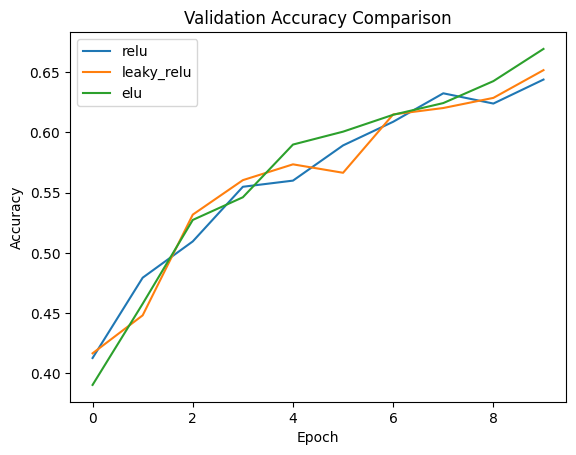

relu: Test Acc=0.6422, Time=38.91s
leaky_relu: Test Acc=0.6539, Time=36.86s
elu: Test Acc=0.6624, Time=40.95s


In [9]:
# Cell No: 8
def main():
    results = run_activation_experiment()
    plot_activation_results(results)

    for act, res in results.items():
        print(f"{act}: Test Acc={res['test_acc']:.4f}, Time={res['time']:.2f}s")

main()